# Visualize Paper and BPIC12 dataset training outcomes


In [102]:
import matplotlib
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pickle,os
sns.set_style('white')
microsoft_colors = sns.color_palette(['#01b8aa', '#374649', '#fd625e', '#f2c80f', '#5f6b6d',
                                      '#8ad4eb', '#fe9666', '#a66999', '#3599b8', '#dfbfbf'])
%config InlineBackend.figure_format = 'retina'

axis	ad	process_model	dataset_name	f1	precision	recall

Case	SmallDAE	Small	small-0.3-1	0.482654693	0.648148148	0.384483468

Case	SmallDAE-Leaky-10	Small	small-0.3-1	0.509720861	0.648148148	0.420016463

Case	SmallDAE-Leaky-100	Small	small-0.3-1	0.482654693	0.648148148	0.384483468




In [103]:
def process_excel(file_path):
    df = pd.read_excel(file_path)
    # columns ['axis', 'ad', 'process_model', 'dataset_name', 'f1', 'precision', 'recall']
    return df

In [104]:
paper_leaky_path = ".out\\plots\\paper_dae.xlsx"
paper_frozen_path = ".out\\plots\\paper_ltn.xlsx"
bpic12_leaky_path = ".out\\plots\\bpic12_dae.xlsx"
bpic12_frozen_path = ".out\\plots\\bpic12_ltn.xlsx"

paper_leaky_df = pd.read_excel(paper_leaky_path)
paper_frozen_df = pd.read_excel(paper_frozen_path)
bpic12_leaky_df = pd.read_excel(bpic12_leaky_path)
bpic12_frozen_df = pd.read_excel(bpic12_frozen_path)

paper_leaky_df = paper_leaky_df[["examples", "avg"]].rename(columns={"examples": "rows", "avg": "f1"})
paper_frozen_df = paper_frozen_df[["examples", "avg"]].rename(columns={"examples": "rows", "avg": "f1"})
bpic12_leaky_df = bpic12_leaky_df[["examples", "avg"]].rename(columns={"examples": "rows", "avg": "f1"})
bpic12_frozen_df = bpic12_frozen_df[["examples", "avg"]].rename(columns={"examples": "rows", "avg": "f1"})

paper_leaky_df["process_model"] = "paper"
paper_leaky_df["type"] = "leaky"

paper_frozen_df["process_model"] = "paper"
paper_frozen_df["type"] = "frozen"

bpic12_leaky_df["process_model"] = "bpic12"
bpic12_leaky_df["type"] = "leaky"

bpic12_frozen_df["process_model"] = "bpic12"
bpic12_frozen_df["type"] = "frozen"

# print(paper_leaky_df)
# print(paper_frozen_df)
# print(bpic12_leaky_df)
# print(bpic12_frozen_df)

In [105]:
synth_datasets = [ 'p2p', 'small', 'medium', 'large', 'huge', 'gigantic', 'wide']
bpic_datasets = [ 'bpic13', 'bpic17']
datasets = synth_datasets + bpic_datasets
result_folders_path = f'.out/plots/{datasets[0]}'
def aggregate_result_excels_in_folders(result_folders_path):
    all_dfs = []
    for root, dirs, files in os.walk(result_folders_path):
        for file in files:
            if "leaky" not in file and "frozen" not in file and  "declare" not in file and "table" not in file and file.endswith('.xlsx'):
                df = process_excel(os.path.join(root, file))
                all_dfs.append(df)
    return pd.concat(all_dfs, ignore_index=True)

# the max "row" column value in the dataframe should be 300
def df_to_df_with_max_rows_value_300(df):
    return df[df['rows'] <= 300]

def process_concatenated_df(concatenated_df):

    concatenated_df = aggregate_result_excels_in_folders(result_folders_path)
    # groupby and mean the results
    grouped_df = concatenated_df.groupby(['axis', 'ad', 'process_model', 'dataset_name']).mean().reset_index()
    # create a new column called rows, created by splitting the ad with "-" and choosing the last element
    grouped_df['rows'] = grouped_df['ad'].str.split('-').str[-1].fillna(0)
    #row which does not have "-" in ad should be set to 0 for rows column
    grouped_df.loc[~grouped_df['ad'].str.contains('-'), 'rows'] = 0
    #rows should be after ad ['axis', 'ad', 'process_model', 'dataset_name', 'f1', 'precision',
    #       'recall', 'rows']
    # make rows an integer column
    grouped_df['rows'] = grouped_df['rows'].astype(int)
    grouped_df[['f1', 'precision', 'recall']] = grouped_df[['f1', 'precision', 'recall']].astype(float)

    grouped_df = grouped_df[['ad','rows', 'process_model', 'f1', 'precision', 'recall']]

    leaky_df = grouped_df[grouped_df['ad'].str.contains('Leaky')].copy().reset_index(drop=True)
    frozen_df = grouped_df[grouped_df['ad'].str.contains('FROZEN')].copy().reset_index(drop=True)
    # add the row in grouped_df which has rows=0 to both leaky_df and frozen_df
    # AttributeError: 'DataFrame' object has no attribute 'append'
    leaky_df = pd.concat([leaky_df, grouped_df[grouped_df['rows'] == 0]]).drop("ad", axis=1).sort_values(by='rows')
    frozen_df = pd.concat([frozen_df, grouped_df[grouped_df['rows'] == 0]]).drop("ad", axis=1).sort_values(by='rows')
    # add a column to leaky which says leaky, and frozen to frozen
    leaky_df['type'] = 'leaky'
    frozen_df['type'] = 'frozen'
    #make type the first column
    leaky_df = leaky_df[['type'] + [col for col in leaky_df.columns if col != 'type']]
    frozen_df = frozen_df[['type'] + [col for col in frozen_df.columns if col != 'type']]
    leaky_df = leaky_df.reset_index(drop=True)
    frozen_df = frozen_df.reset_index(drop=True)
    leaky_df = df_to_df_with_max_rows_value_300(leaky_df)
    frozen_df = df_to_df_with_max_rows_value_300(frozen_df)
    print(leaky_df)
    print(frozen_df)
    leaky_df.to_excel(result_folders_path + '/leaky.xlsx', index=False)
    frozen_df.to_excel(result_folders_path + '/frozen.xlsx', index=False)
    return leaky_df, frozen_df


In [106]:
dfs = {}
for dataset in datasets:
    result_folders_path = f'.out/plots/{dataset}'
    leaky_df, frozen_df = process_concatenated_df(aggregate_result_excels_in_folders(result_folders_path))
    dfs[dataset] = (dataset, leaky_df, frozen_df)
dfs["paper"] = ("paper", df_to_df_with_max_rows_value_300(paper_leaky_df), df_to_df_with_max_rows_value_300(paper_frozen_df))
dfs["bpic12"] = ("bpic12", df_to_df_with_max_rows_value_300(bpic12_leaky_df), df_to_df_with_max_rows_value_300(bpic12_frozen_df))

    type  rows process_model        f1  precision    recall
0  leaky     0           P2P  0.437643   0.634202  0.341189
1  leaky    10           P2P  0.386118   0.695187  0.272218
2  leaky    25           P2P  0.376460   0.716677  0.257624
3  leaky    50           P2P  0.384001   0.712125  0.276740
4  leaky   100           P2P  0.376113   0.728577  0.257624
5  leaky   150           P2P  0.389580   0.713581  0.268331
6  leaky   200           P2P  0.361190   0.723703  0.246666
7  leaky   250           P2P  0.406389   0.730021  0.288806
8  leaky   300           P2P  0.408851   0.724359  0.285946
     type  rows process_model        f1  precision    recall
0  frozen     0           P2P  0.437643   0.634202  0.341189
1  frozen    10           P2P  0.457614   0.622483  0.364233
2  frozen    25           P2P  0.476087   0.561891  0.418913
3  frozen    50           P2P  0.506249   0.584924  0.454305
4  frozen   100           P2P  0.492596   0.551025  0.458182
5  frozen   150           P2P  0.4

In [107]:
def visualize_ltn_and_leaky(leaky_df, frozen_df, dataset_name, fig_save_filename):
    """
    ltn_df: DataFrame with columns examples, avg
    leaky_df: DataFrame with columns examples, avg
    fig_save_filename: path to save the figure
    
    
    Plot values of ltn_df as a single colored line plot 
    and leaky_df as another single colored line plot, 
    with legend and labels.
    also show the image in the notebook.
    Save the figure to the specified filename.
    """
    # Set the figure size
    plt.figure(figsize=(10, 6))

    # Plot the data
    sns.lineplot(data=frozen_df, x='rows', y='f1', label='LTN', color=microsoft_colors[0])
    sns.lineplot(data=leaky_df, x='rows', y='f1', label='Standard', color=microsoft_colors[1])

    # Set the title and labels
    plt.title(f'{dataset_name} LTN vs Standard')
    plt.xlabel('Rare Conformant Traces')
    plt.ylabel('F1 Score')

    # show grid
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # start y-axis at 0
    plt.ylim(bottom=0.0, top=1.0)
    plt.xlim(left=0, right=350)

    # Show legend
    # plt.legend()
    
    # always show legend at the top in the graph
    plt.legend(loc='lower left', ncol=1, fontsize=12)
    # plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2, fontsize=12)

    # Save the figure
    plt.savefig(fig_save_filename, format="png", dpi=600, bbox_inches='tight')

    # Show the plot
    plt.show()
    

# Paper dataset

In [108]:
# paper_ltn_df = pd.read_excel(r'D:\LTNcoder\.out\plots\paper_ltn.xlsx')
# paper_leaky_df = pd.read_excel(r'D:\LTNcoder\.out\plots\paper_dae.xlsx')
# paper_fig_path = r'D:\LTNcoder\.out\plots\small_ltn_vs_leaky.png'
# dataset_name = 'Small Dataset'
# visualize_ltn_and_leaky(leaky_df=leaky_df, frozen_df=frozen_df, dataset_name=dataset_name, fig_save_filename=paper_fig_path)


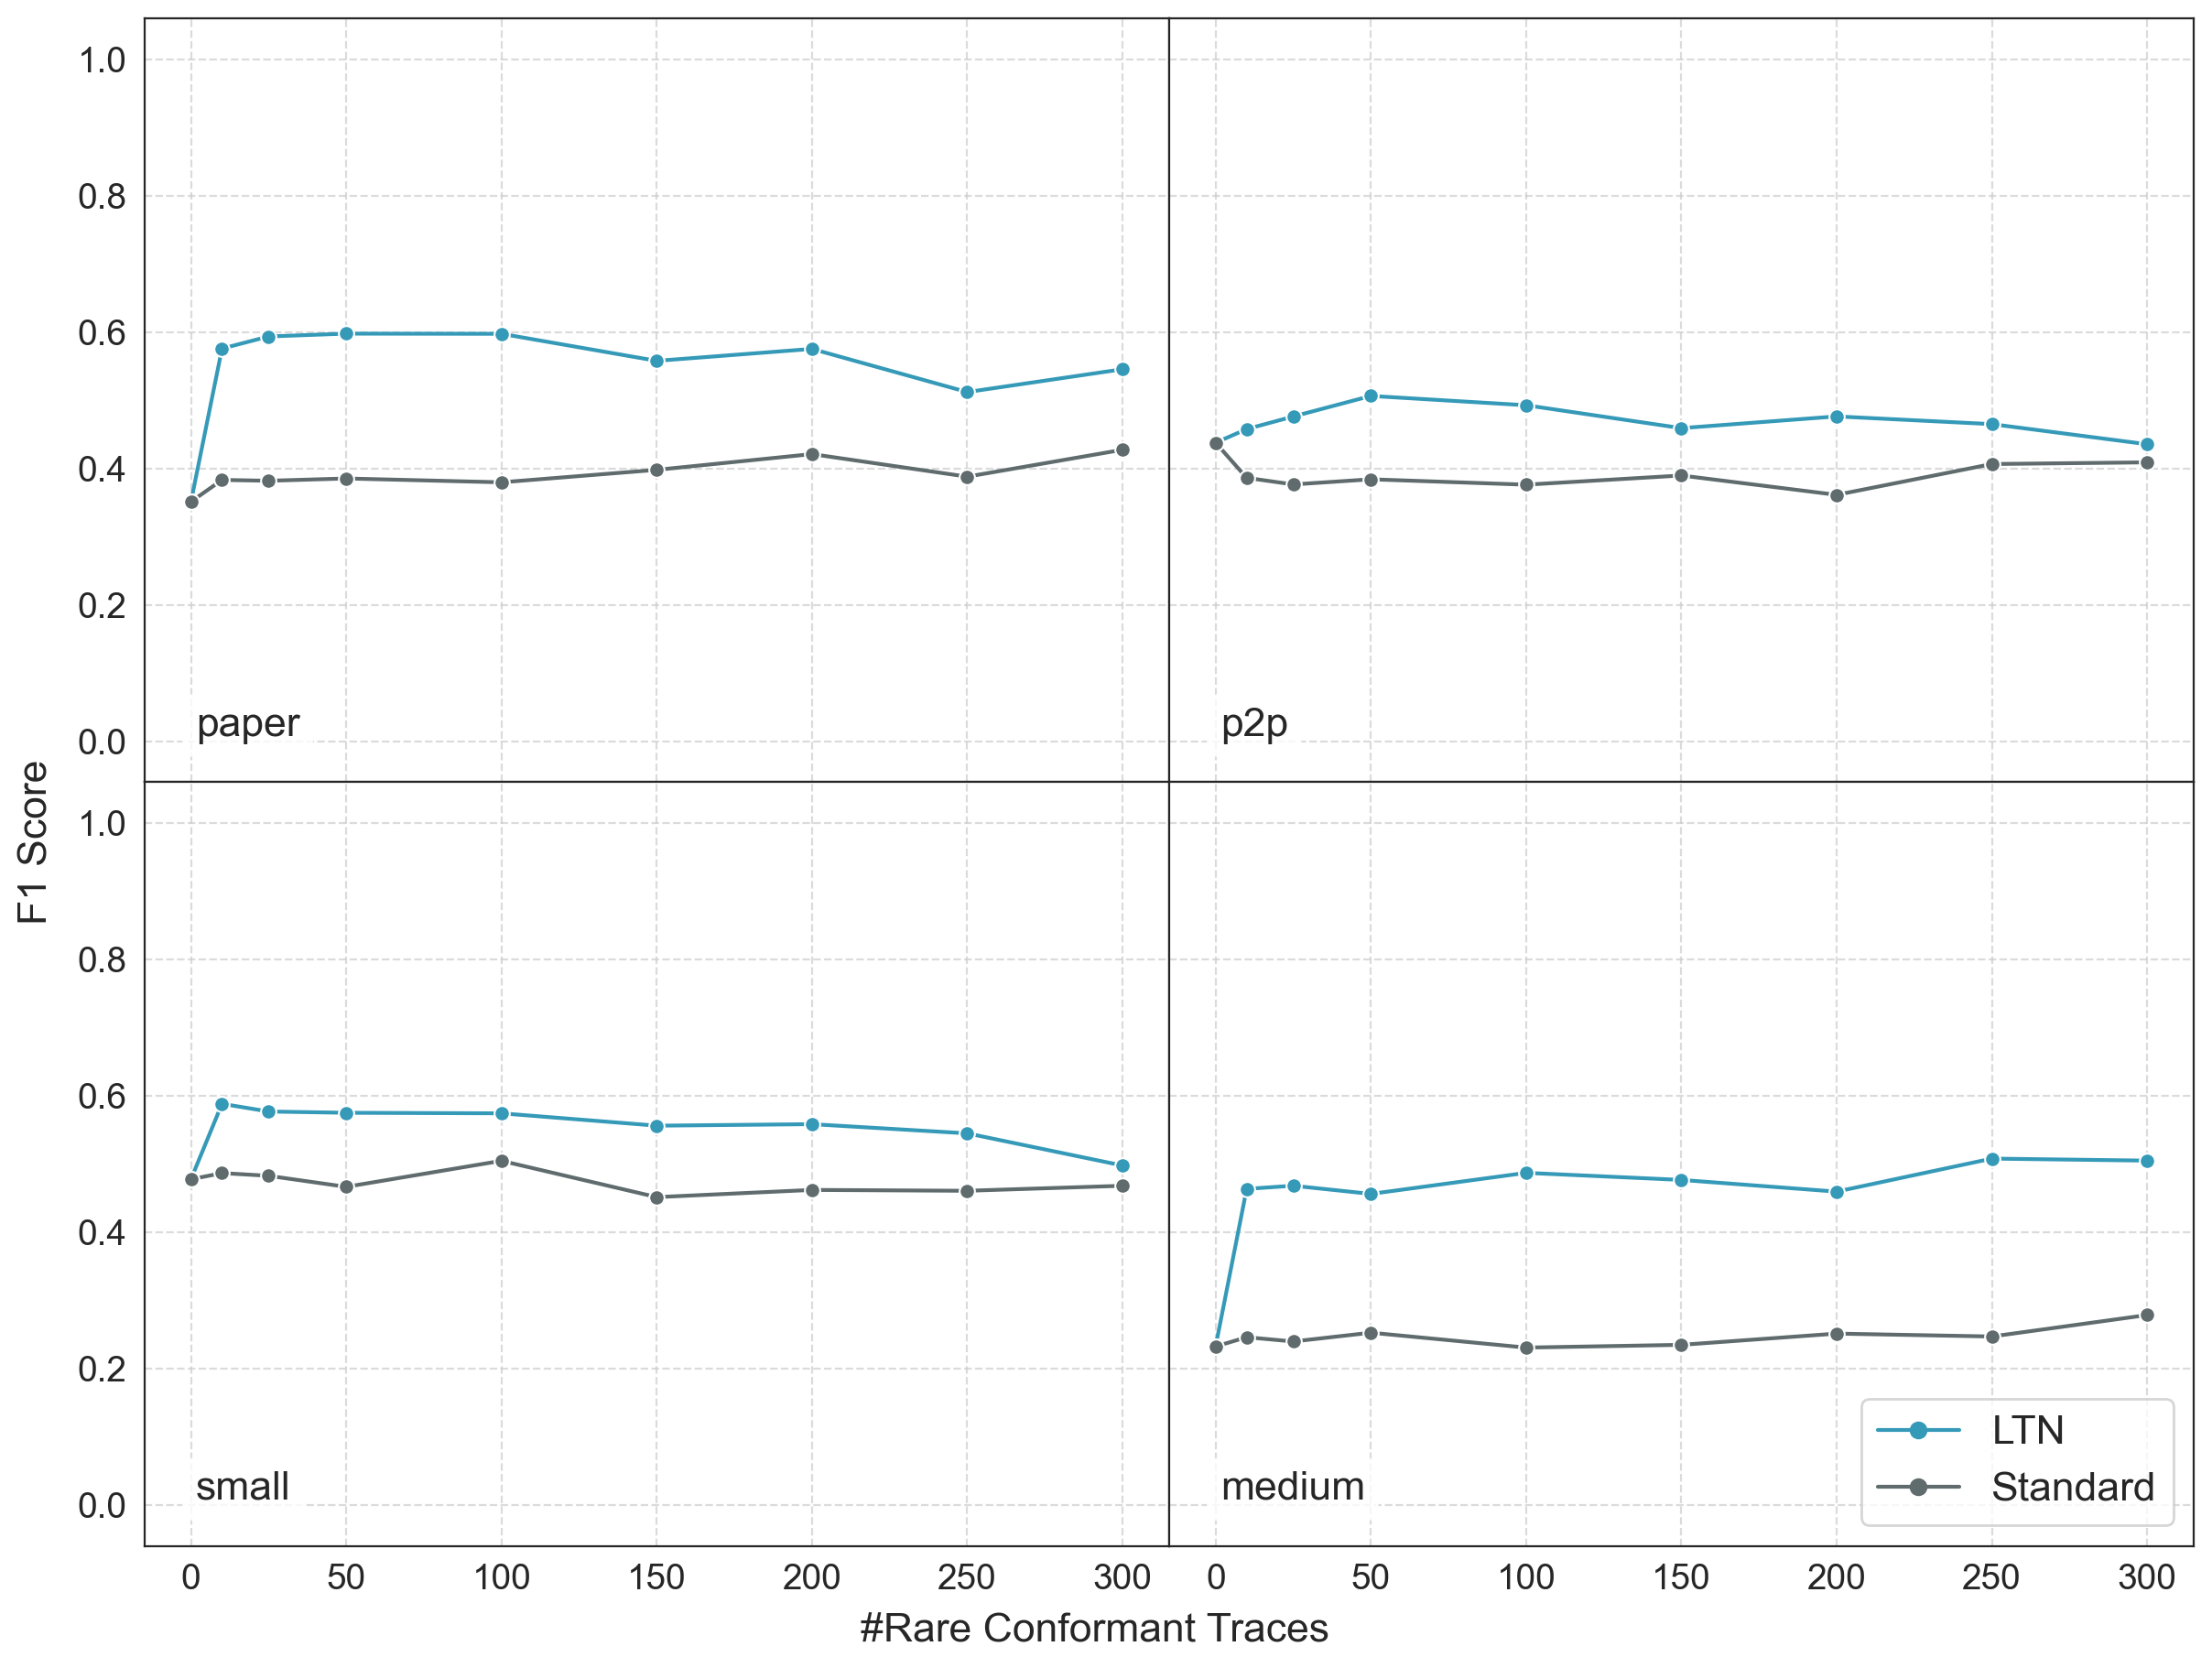

Saved 4-in-1 figure to: .out/plots/eval_paper_p2p_small_medium_4in1.png


In [109]:
def visualize_four_datasets_4in1(
    title1, leaky_df1, frozen_df1,
    title2, leaky_df2, frozen_df2,
    title3, leaky_df3, frozen_df3,
    title4, leaky_df4, frozen_df4,
    save_path = None
):
    pairs = [
        (leaky_df1, frozen_df1),
        (leaky_df2, frozen_df2),
        (leaky_df3, frozen_df3),
        (leaky_df4, frozen_df4),
    ]
    titles = [title1, title2, title3, title4]

    fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=True, sharey=True)
    axes = axes.ravel()
    
    # Remove spacing between subplots
    plt.subplots_adjust(hspace=0, wspace=0)

    for idx, ((leaky, frozen), ax) in enumerate(zip(pairs, axes)):
        leaky = leaky.sort_values('rows')
        frozen = frozen.sort_values('rows')

        sns.lineplot(data=frozen, x='rows', y='f1', ax=ax, label='LTN', color=microsoft_colors[8], marker='o')
        sns.lineplot(data=leaky, x='rows', y='f1', ax=ax, label='Standard', color=microsoft_colors[4], marker='o')

        # Add title in bottom left corner of each subplot
        ax.text(0.05, 0.05, titles[idx], transform=ax.transAxes, fontsize=16, 
                verticalalignment='bottom', horizontalalignment='left',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
        
        ax.grid(True, linestyle='--', alpha=0.7)
        ax.set_xlim(-15, 315)
        ax.set_ylim(-0.06, 1.06)
        
        # Increase font size of axis tick labels
        ax.tick_params(axis='x', labelsize=14)
        ax.tick_params(axis='y', labelsize=14)

        # Remove all individual axis labels
        ax.set_xlabel('')
        ax.set_ylabel('')

        # Add legend only to bottom right subplot (index 3)
        if idx == 3:
            handles = [
                matplotlib.lines.Line2D([0], [0], color=microsoft_colors[8], marker='o', label='LTN'),
                matplotlib.lines.Line2D([0], [0], color=microsoft_colors[4], marker='o', label='Standard'),
            ]
            ax.legend(handles=handles, loc='lower right', ncol=1, frameon=True, fontsize=16)
        else:
            # Remove per-axes legends for other subplots
            leg = ax.get_legend()
            if leg is not None:
                leg.remove()

    # Add shared axis labels with larger font
    fig.supxlabel('#Rare Conformant Traces', fontsize=16, y=0.01)
    fig.supylabel('F1 Score', fontsize=16, x=0.01)

    # Use tight_layout with padding to accommodate the legend and title
    fig.tight_layout(rect=[0.02, 0.02, 1, 1], pad=0)

    if save_path is None:
        save_path = f'.out/plots/eval_{title1}_{title2}_{title3}_{title4}_4in1.png'
    fig.savefig(save_path, dpi=600, bbox_inches='tight')
    plt.show()
    return fig, axes, save_path

# Trial: use the small dataset dataframes for all inputs
_, _, four_in_one_path = visualize_four_datasets_4in1(
    title1 =dfs["paper"][0], leaky_df1 = dfs["paper"][1], frozen_df1 = dfs["paper"][2],
    title2 =dfs["p2p"][0], leaky_df2 = dfs["p2p"][1], frozen_df2 = dfs["p2p"][2],
    title3 =dfs["small"][0], leaky_df3 = dfs["small"][1], frozen_df3 = dfs["small"][2],
    title4 =dfs["medium"][0], leaky_df4 = dfs["medium"][1], frozen_df4 = dfs["medium"][2]
)
print(f"Saved 4-in-1 figure to: {four_in_one_path}")

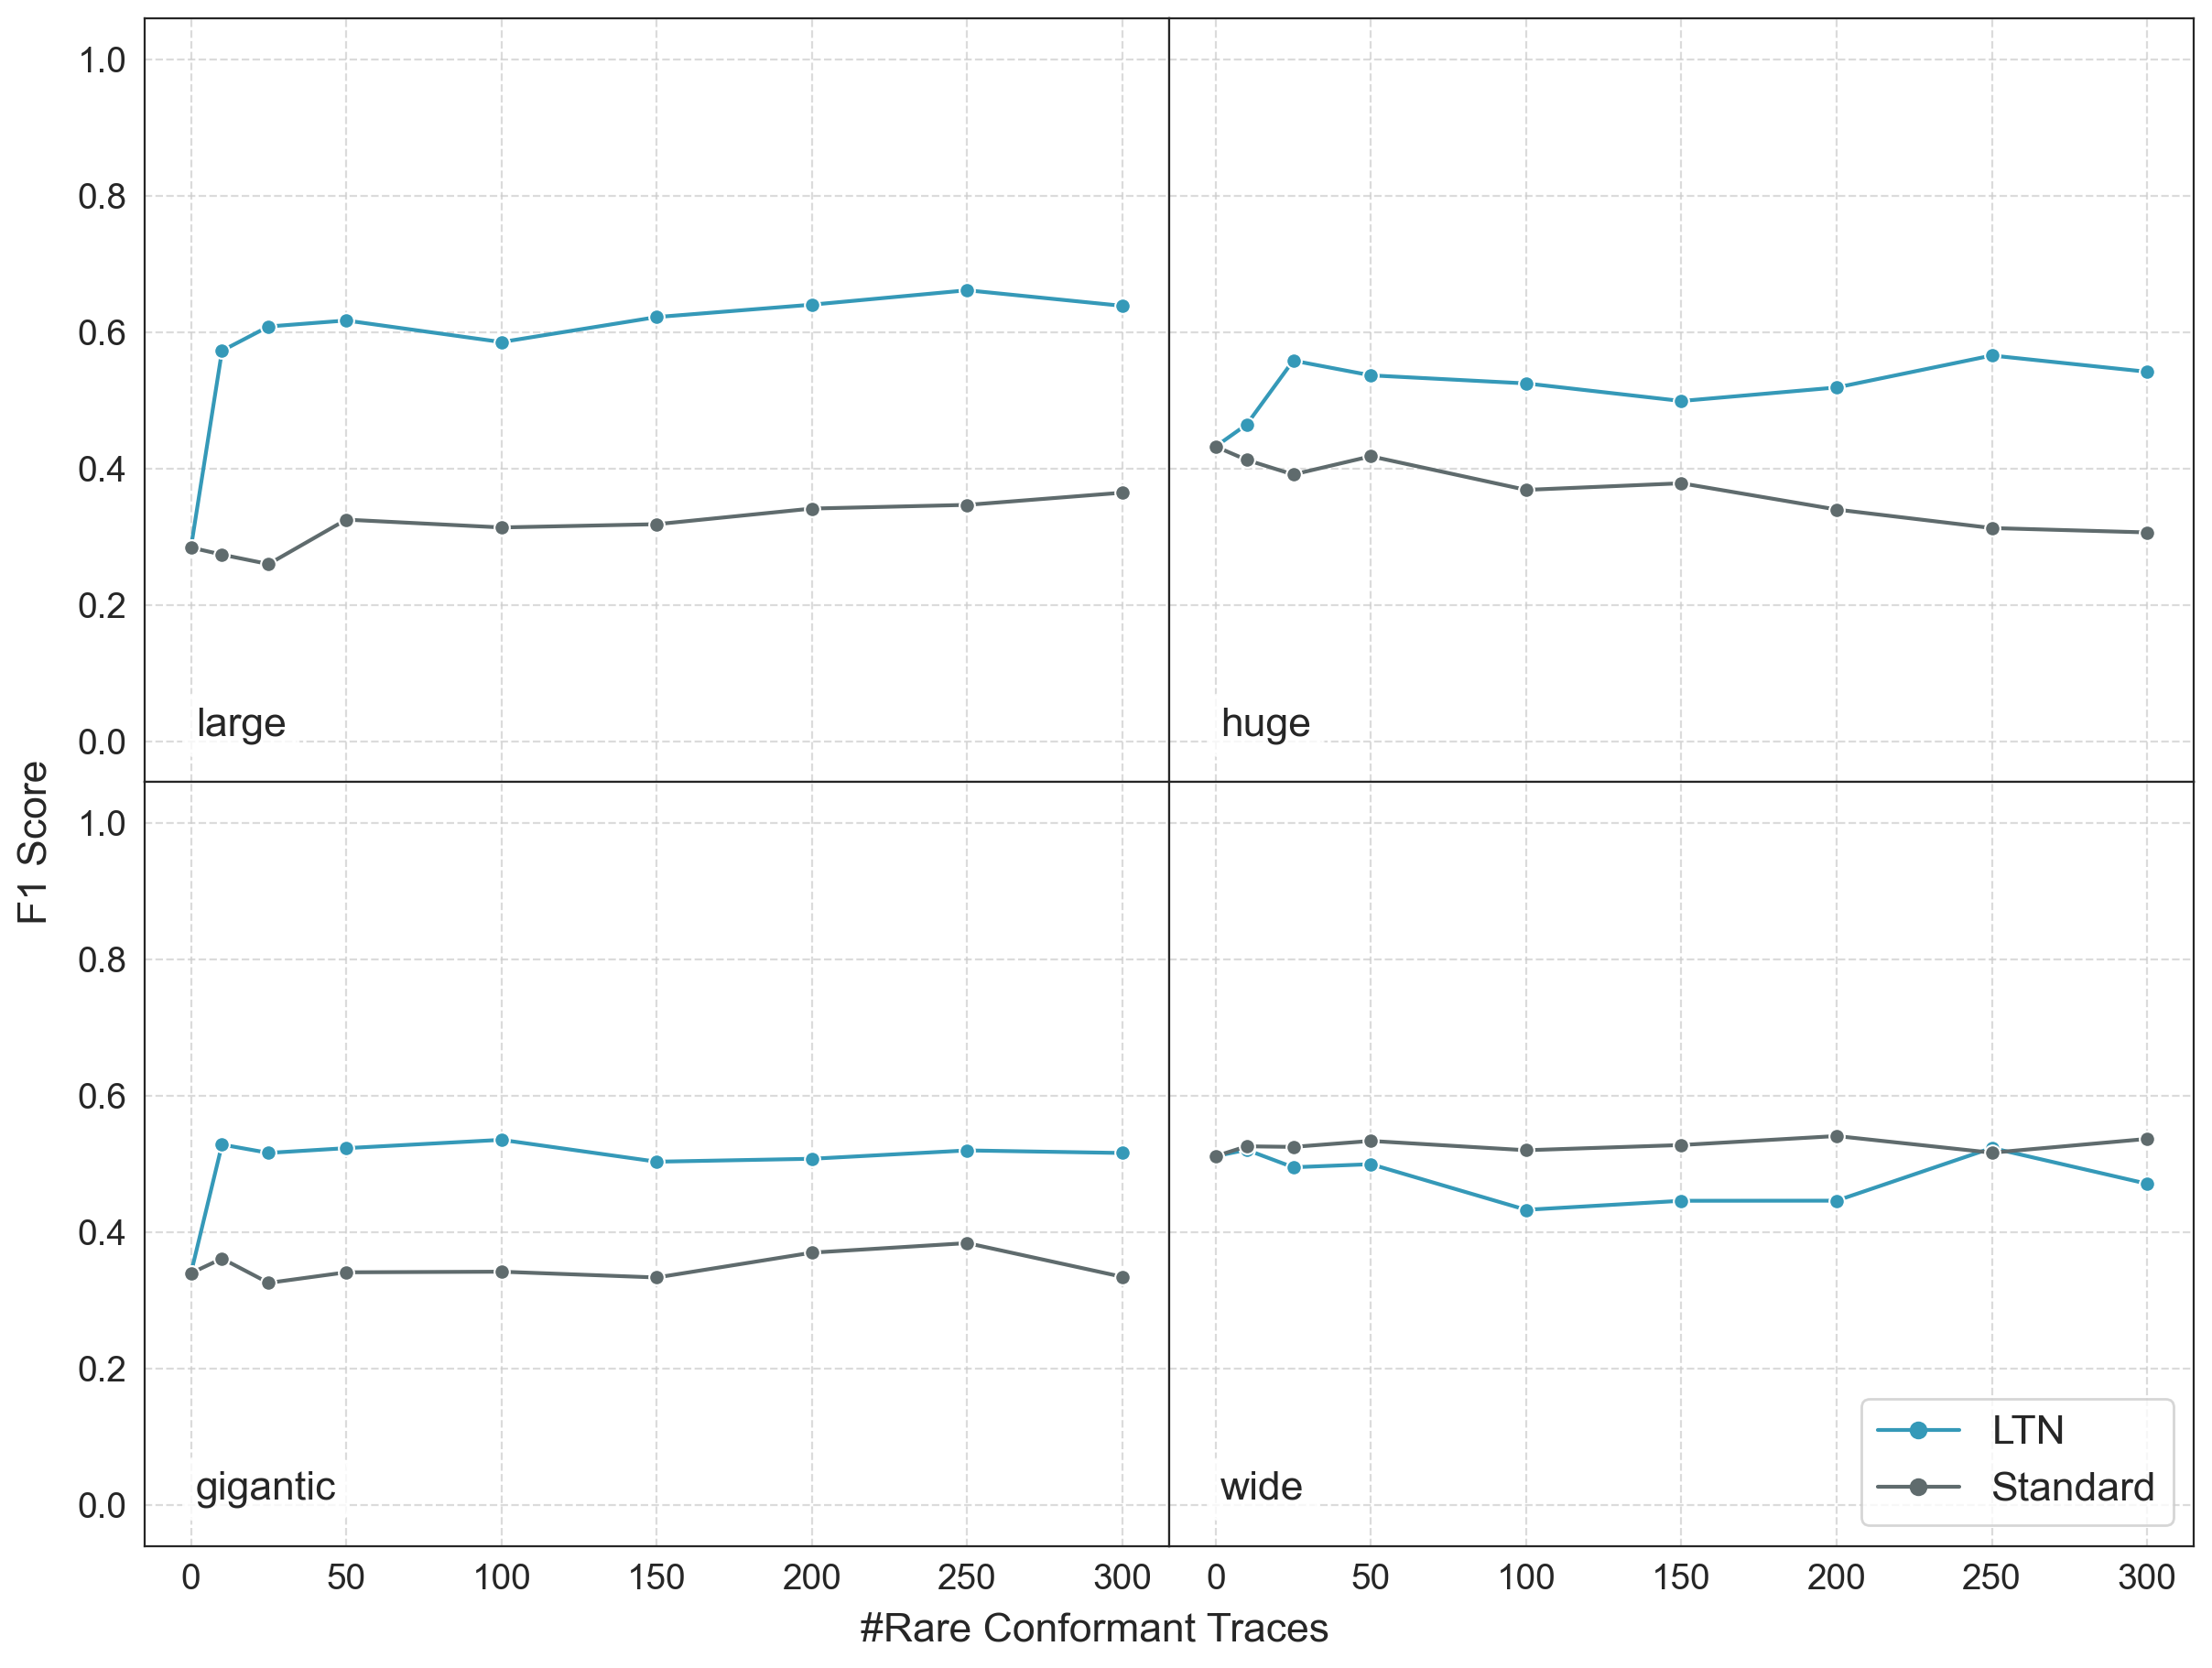

Saved 4-in-1 figure to: .out/plots/eval_large_huge_gigantic_wide_4in1.png


In [110]:
_, _, four_in_one_path = visualize_four_datasets_4in1(
    title1 =dfs["large"][0], leaky_df1 = dfs["large"][1], frozen_df1 = dfs["large"][2],
    title2 =dfs["huge"][0], leaky_df2 = dfs["huge"][1], frozen_df2 = dfs["huge"][2],
    title3 =dfs["gigantic"][0], leaky_df3 = dfs["gigantic"][1], frozen_df3 = dfs["gigantic"][2],
    title4 =dfs["wide"][0], leaky_df4 = dfs["wide"][1], frozen_df4 = dfs["wide"][2]
)
print(f"Saved 4-in-1 figure to: {four_in_one_path}")

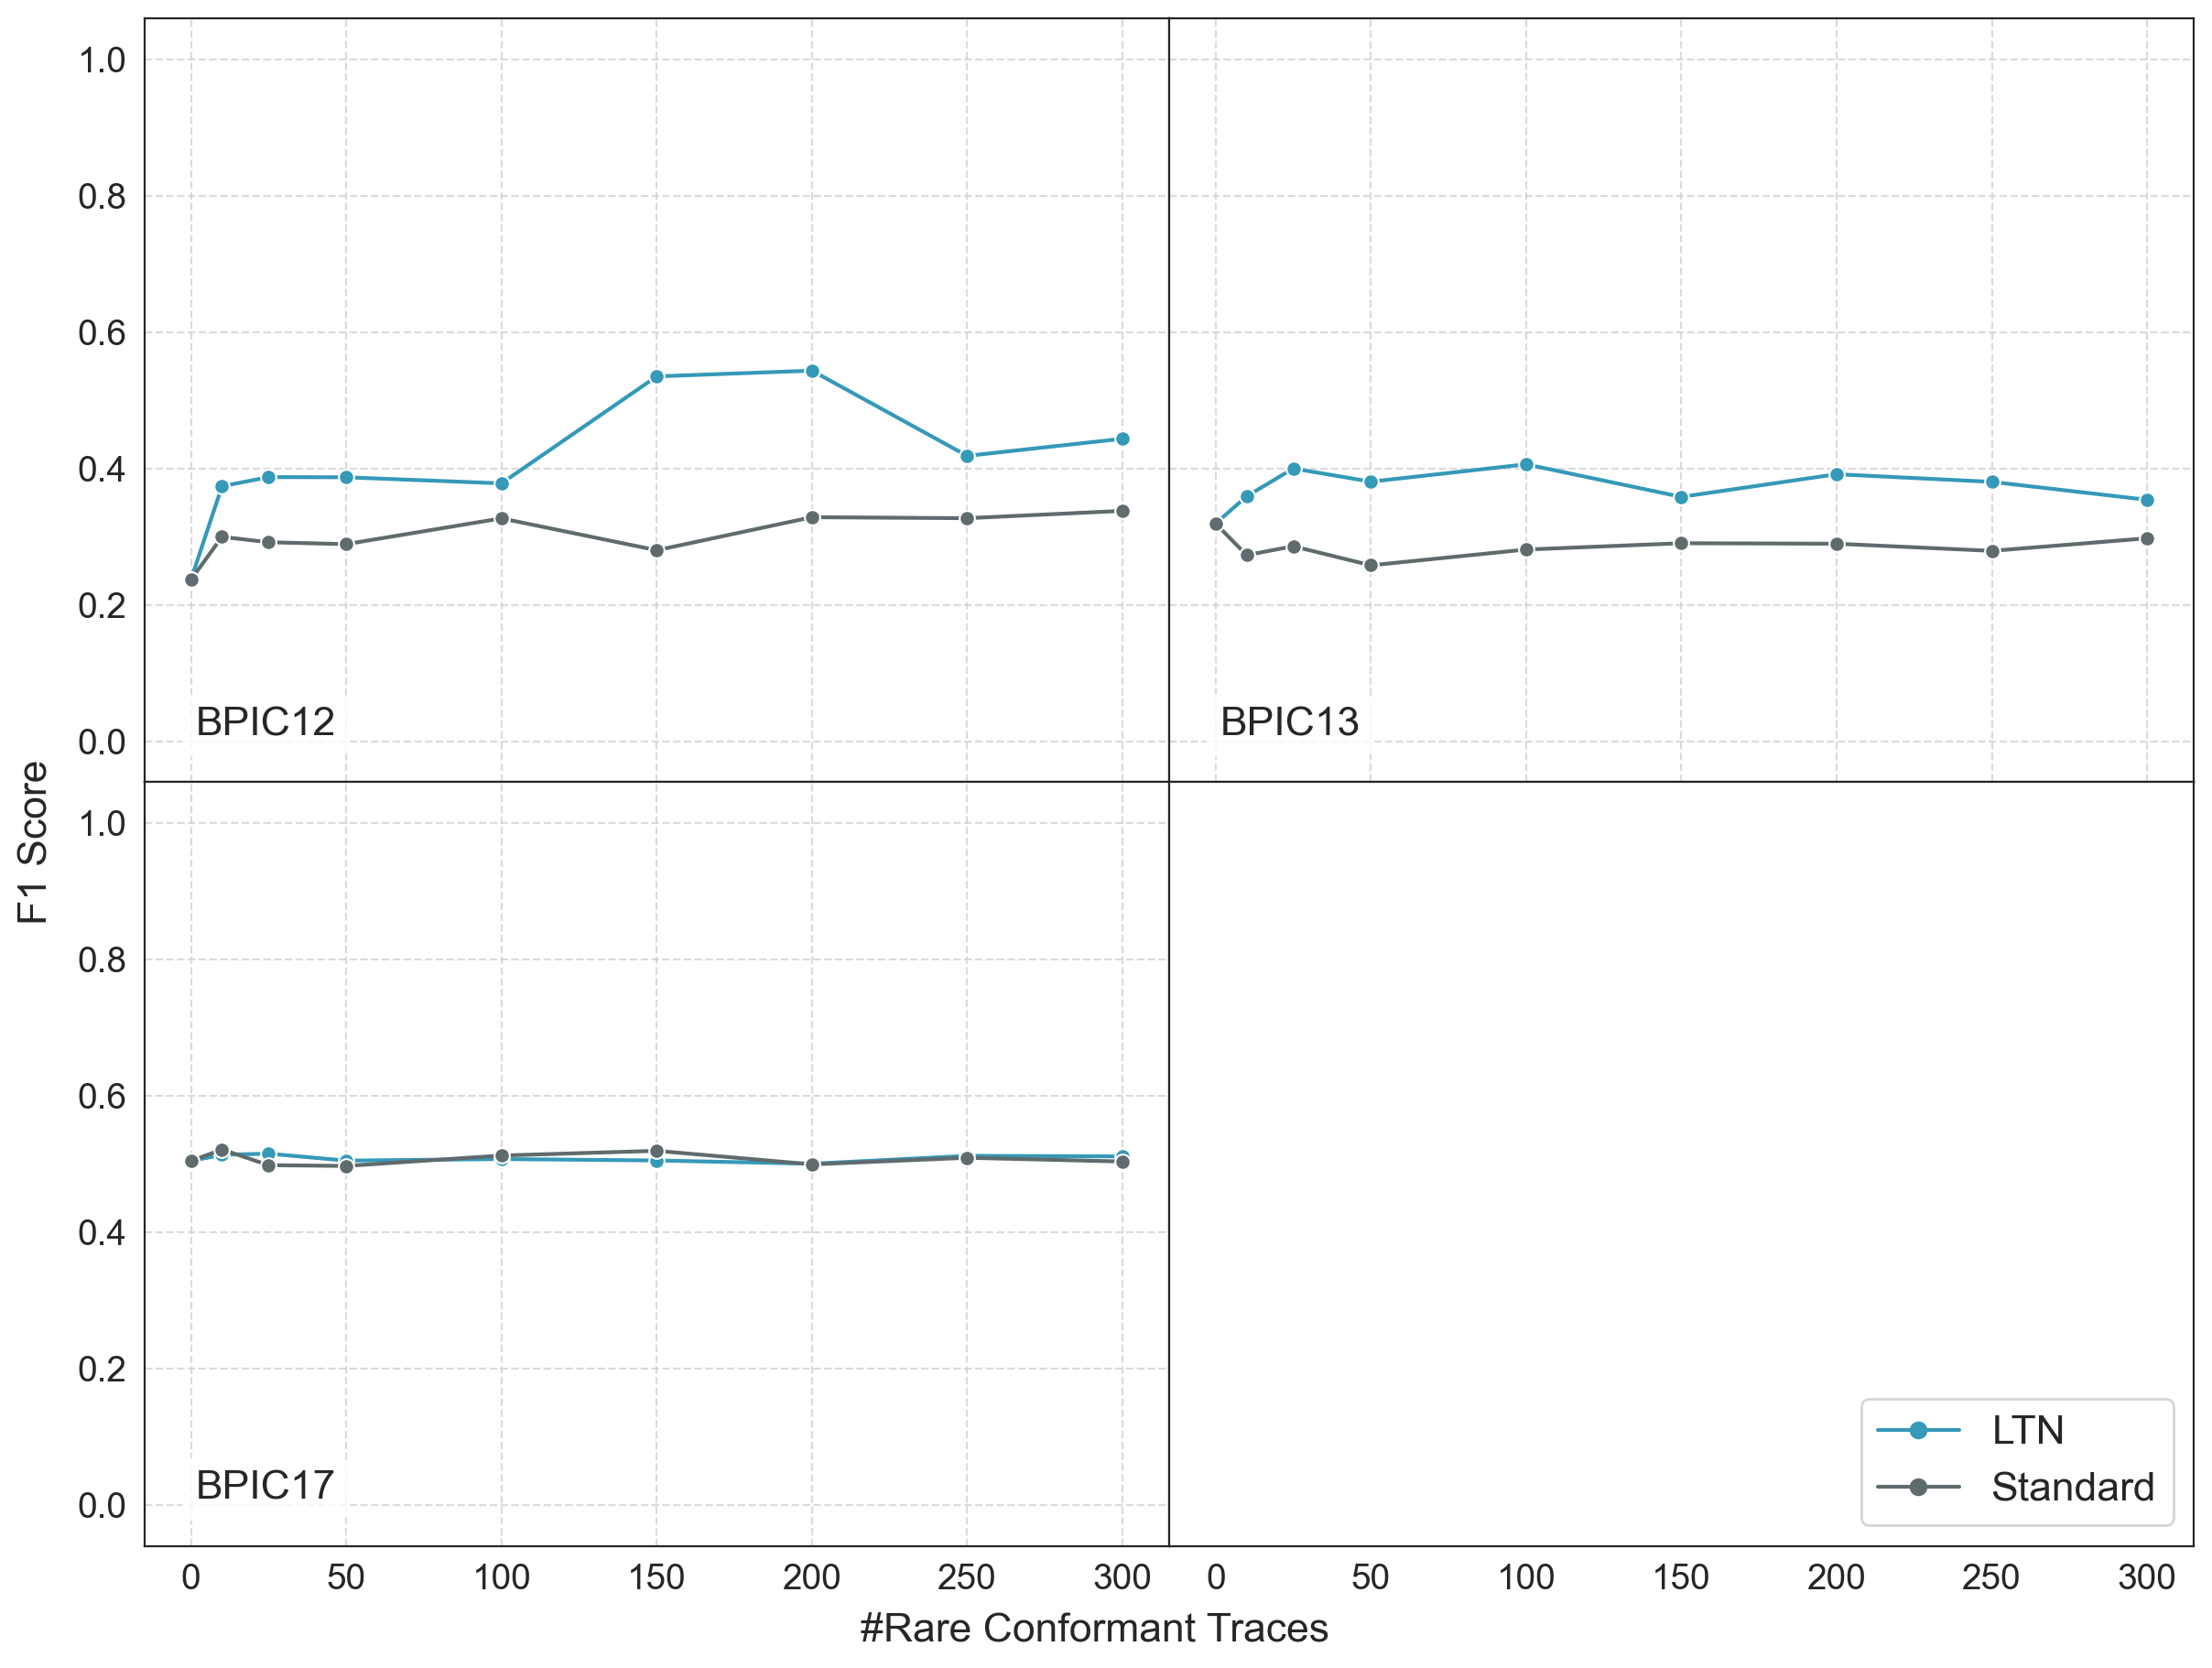

Saved 3-in-1 figure to: .out/plots/eval_bpic12_bpic13_bpic17_3in1.png


In [111]:
def visualize_three_datasets_3in1(
    title1:str, leaky_df1, frozen_df1,
    title2:str, leaky_df2, frozen_df2,
    title3:str, leaky_df3, frozen_df3,
    save_path = None
):
    pairs = [
        (leaky_df1, frozen_df1),
        (leaky_df2, frozen_df2),
        (leaky_df3, frozen_df3),
    ]
    titles = [title1.upper(), title2.upper(), title3.upper()]

    fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=True, sharey=True)
    axes = axes.ravel()
    
    # Remove spacing between subplots
    plt.subplots_adjust(hspace=0, wspace=0)

    for idx, ((leaky, frozen), ax) in enumerate(zip(pairs, axes[:3])):
        leaky = leaky.sort_values('rows')
        frozen = frozen.sort_values('rows')

        sns.lineplot(data=frozen, x='rows', y='f1', ax=ax, label='LTN', color=microsoft_colors[8], marker='o')
        sns.lineplot(data=leaky, x='rows', y='f1', ax=ax, label='Standard', color=microsoft_colors[4], marker='o')

        # Add title in bottom left corner of each subplot
        ax.text(0.05, 0.05, titles[idx], transform=ax.transAxes, fontsize=16, 
                verticalalignment='bottom', horizontalalignment='left',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
        
        ax.grid(True, linestyle='--', alpha=0.7)
        ax.set_xlim(-15, 315)
        ax.set_ylim(-0.06, 1.06)
        
        # Increase font size of axis tick labels
        ax.tick_params(axis='x', labelsize=14)
        ax.tick_params(axis='y', labelsize=14)

        # Remove all individual axis labels
        ax.set_xlabel('')
        ax.set_ylabel('')

        # Add legend only to bottom right subplot (index 3)
        if idx == 3:
            handles = [
                matplotlib.lines.Line2D([0], [0], color=microsoft_colors[8], marker='o', label='LTN'),
                matplotlib.lines.Line2D([0], [0], color=microsoft_colors[4], marker='o', label='Standard'),
            ]
            ax.legend(handles=handles, loc='lower right', ncol=1, frameon=True, fontsize=16)
        else:
            # Remove per-axes legends for other subplots
            leg = ax.get_legend()
            if leg is not None:
                leg.remove()


    # set similar settings for 4th axis
    ax = axes[3]
    ax.tick_params(axis='x', labelsize=14)
    ax.tick_params(axis='y', labelsize=14)
    handles = [
                matplotlib.lines.Line2D([0], [0], color=microsoft_colors[8], marker='o', label='LTN'),
                matplotlib.lines.Line2D([0], [0], color=microsoft_colors[4], marker='o', label='Standard'),
            ]
    ax.legend(handles=handles, loc='lower right', ncol=1, frameon=True, fontsize=16)

    # Add shared axis labels with larger font
    fig.supxlabel('#Rare Conformant Traces', fontsize=16, y=0.01)
    fig.supylabel('F1 Score', fontsize=16, x=0.01)

    # Use tight_layout with padding to accommodate the legend and title
    fig.tight_layout(rect=[0.02, 0.02, 1, 1], pad=0)

    if save_path is None:
        save_path = f'.out/plots/eval_{title1}_{title2}_{title3}_3in1.png'
    fig.savefig(save_path, dpi=600, bbox_inches='tight')
    plt.show()
    return fig, axes, save_path

# Trial: use the small dataset dataframes for all inputs
_, _, three_in_one_path = visualize_three_datasets_3in1(
    title1 =dfs["bpic12"][0], leaky_df1 = dfs["bpic12"][1], frozen_df1 = dfs["bpic12"][2],
    title2 =dfs["bpic13"][0], leaky_df2 = dfs["bpic13"][1], frozen_df2 = dfs["bpic13"][2],
    title3 =dfs["bpic17"][0], leaky_df3 = dfs["bpic17"][1], frozen_df3 = dfs["bpic17"][2],
)
print(f"Saved 3-in-1 figure to: {three_in_one_path}")